In [22]:
import importlib
importlib.reload(data_prep)

<module 'data_prep' from '/Users/ehabhasan/Documents/Projects/Predictive Modeling/Procurement KPI Analysis and Modeling copy/data_prep.py'>

In [23]:
import pandas as pd
import data_prep
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Avoid line wrapping
pd.set_option('display.max_colwidth', None) # Show full content of each cell

# Data Loading

In [29]:
data=pd.read_csv('Dataset/file.csv')
data['Order_Date']=pd.to_datetime(data['Order_Date'])
data['Delivery_Date']=pd.to_datetime(data['Delivery_Date'])
data.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


# Metadata Analysis

| **Column**            | **Data Type**        | **Summary of Findings**                                                                    |
| --------------------- | -------------------- | ------------------------------------------------------------------------------------------ |
| **PO\_ID**            | Text (ID)            | Unique identifier, high cardinality, no nulls. High entropy confirms uniqueness.           |
| **Supplier**          | Categorical          | 5 suppliers; well-distributed; Delta\_Logistics is the mode. Clean and low cardinality.    |
| **Order\_Date**       | Datetime             | Clean and complete; wide date range; good entropy. Suitable for time-based analysis.       |
| **Delivery\_Date**    | Datetime             | \~11% missing values (87 nulls); otherwise distributed well. Should be cleaned or flagged. |
| **Item\_Category**    | Categorical          | 5 categories; no nulls; Office Supplies is most frequent. Good for grouping.               |
| **Order\_Status**     | Categorical          | 4 statuses; skewed toward "Delivered". Clean and usable for process tracking.              |
| **Quantity**          | Continuous (Integer) | Wide range (51–5000); right-skewed; moderate outliers. Consider normalization.             |
| **Unit\_Price**       | Continuous (Float)   | Symmetric; no outliers; smooth distribution. Ready for modeling.                           |
| **Negotiated\_Price** | Continuous (Float)   | Similar to Unit\_Price; slightly lower mean; useful for discount analysis.                 |
| **Defective\_Units**  | Continuous (Float)   | 17.5% missing values; right-skewed with outliers. Needs cleaning and treatment.            |
| **Compliance**        | Categorical (Binary) | Only 2 values; skewed toward "Yes". Can be used in compliance rate checks.                 |


In [8]:
data_prep.DatasetMetadata(data)

The dataset includes 11 columns and 777 rows
Dataset has 0 duplicate rows
Memory Usage of the DataFrame: 0.28 MB
--------------------------


,CName,DType,UsageMB,VarType,Cardinality,Null*,Empty*,Mode,Mean,Std,Min,Max,Skewness,Kurtosis,Q1,Q2/Median,Q3,Outliers %,Entropy,Max Entropy
0,PO_ID,object,0.05,Text,777,0,0,PO-00001,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,9.60,9.60
1,Supplier,object,0.05,Text,5,0,0,Delta_Logistics,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,2.32,2.32
2,Order_Date,datetime64[ns],0.01,Date,476,0,0,2022-09-29 00:00:00,2022-12-28 23:15:31.274131456,211 days 08:58:00.464259680,2022-01-01 00:00:00,2024-01-01 00:00:00,N/A,N/A,2022-07-02 00:00:00,2022-12-24 00:00:00,2023-07-07 00:00:00,0.0,8.72,8.89
3,Delivery_Date,datetime64[ns],0.01,Date,449,87,0,2022-02-13 00:00:00,2023-01-12 03:16:10.434782720,211 days 05:51:11.574281812,2022-01-06 00:00:00,2024-01-12 00:00:00,N/A,N/A,2022-07-19 18:00:00,2023-01-19 12:00:00,2023-07-18 00:00:00,0.0,8.66,8.81
4,Item_Category,object,0.05,Text,5,0,0,Office Supplies,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,2.32,2.32
5,Order_Status,object,0.05,Text,4,0,0,Delivered,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,1.30,2.00
6,Quantity,int64,0.01,Continuous,623,0,0,5000,1094.660232,647.844551,51,5000,1.55,8.28,615.0,1075.0,1548.0,0.77,9.18,9.28
7,Unit_Price,float64,0.01,Continuous,747,0,0,17.78,58.283822,28.101315,10.84,109.17,0.03,-1.24,33.29,58.95,83.13,0.0,9.52,9.54
8,Negotiated_Price,float64,0.01,Continuous,752,0,0,12.79,53.660721,26.09493,9.27,107.39,0.07,-1.18,30.46,53.8,76.55,0.0,9.54,9.55
9,Defective_Units,float64,0.01,Continuous,202,136,0,29.0,74.803432,69.18787,0.0,321.0,1.38,1.19,26.0,49.0,100.0,5.15,7.22,7.66


# Data Wrangling

In [30]:
# No records found where Negotiated_Price exceeds Unit_Price — this confirms pricing integrity is maintained.
data[data['Negotiated_Price']>data['Unit_Price']]

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance


- The code below shows that there are gaps in both Order_Date and Delivery_Date. In time series modeling or forecasting, such gaps can violate the assumption of regular time intervals, potentially misleading the model and degrading forecast accuracy.

In [31]:
data_prep.CheckGap(data,'Order_Date','d',False)

'The Order_Date has gap = 255'

In [32]:
data_prep.CheckGap(data,'Delivery_Date','d',False)

'The Delivery_Date has gap = 288'

- The data has no duplicates after excluding 'Unit_Price' and 'Negotiated_Price'

In [33]:
data_prep.duplicate_check(data,['Unit_Price','Negotiated_Price'],True)

"0 duplicate group(s) found based on key columns excluding: ['Unit_Price', 'Negotiated_Price']"

> I identified several data quality issues related to the assignment of delivery dates:
>
> * Some **cancelled or pending orders** have a delivery date assigned (which is illogical).
> * Some **delivered or partially delivered orders** are missing a delivery date.
> * Some records have a **delivery date earlier than or equal to the order date**, which is invalid.
>
> These records are flagged as data quality issues and will be excluded from modeling or further analysis.


In [34]:
# Flag data quality issues based on inconsistencies between order status and delivery date
data['DQ_Ind'] = np.where(
    (
        (data['Order_Status'].isin(['Cancelled', 'Pending']) & data['Delivery_Date'].notna()) |
        (data['Order_Status'].isin(['Delivered', 'Partially Delivered']) & data['Delivery_Date'].isnull()) |
        (data['Delivery_Date'] <= data['Order_Date'])
    ),
    1,  # DQ issue found
    0   # No issue
)


In [35]:
print(f"Number of the records of the dataset after exluding the records with DQ issues: {len(data)- len(data[data['DQ_Ind']==1])}")

Number of the records of the dataset after exluding the records with DQ issues: 573


- Remove the records with DQ issues and create a new DF

In [36]:
clean_data=data[data['DQ_Ind']==0].reset_index()

- The Defective_Units column contains missing values. Assuming that nulls indicate no defects were reported, these missing values will be replaced with zeros.


In [37]:
clean_data['Defective_Units']=clean_data['Defective_Units'].fillna(0)

# EDA & KPI Overview

## Timeliness & Delivery Metrics





| **Metric Name**          | **Description**                                                                      | **Purpose / Business Insight**                                                                |
| ------------------------ | ------------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------------- |
| `lead_time`              | Days between `Order_Date` and `Delivery_Date`.                                       | Measures actual delivery duration. Helps assess supplier efficiency and delivery performance. |
| `lead_time_target`       | The mean (average) value of `lead_time` across all valid deliveries.                 | Serves as a benchmark (SLA proxy) to evaluate if deliveries are on time.                      |
| `is_late`                | Binary flag (1=Late, 0=On time/early) based on comparison with `lead_time_target`.   | Flags whether an order was delivered late relative to the expected delivery SLA.              |
| `expected_delivery_date` | Estimated delivery date calculated as `Order_Date` + `lead_time_target`.             | Used for delay comparison when explicit SLA is not provided.                                  |
| `delivery_delay_days`    | Number of days delivery was late compared to `expected_delivery_date`. Clipped at 0. | Quantifies how late deliveries were (0 if on time or early).                                  |
| `delivery_month`         | Month (YYYY-MM) extracted from `Delivery_Date`.                                      | Enables time-based grouping and trend analysis (e.g., monthly late delivery rates).           |


In [38]:
# Calculate actual delivery duration in days (Lead Time)
clean_data['lead_time'] = (clean_data['Delivery_Date'] - clean_data['Order_Date']).dt.days

# Set the average lead time across all delivered orders as the target delivery duration (SLA proxy)
lead_time_target = clean_data['lead_time'].mean()

# Flag orders as late (1) if delivered after the target lead time, otherwise on time (0)
clean_data['is_late'] = np.where(
    clean_data['Delivery_Date'] > clean_data['Order_Date'] + pd.Timedelta(days=lead_time_target),
    1, # indicate late delivery
    0
)

# Calculate the expected delivery date using the order date and average lead time
clean_data['expected_delivery_date'] = (
    clean_data['Order_Date'] + pd.to_timedelta(lead_time_target, unit='D')
).dt.normalize()

# Compute delay in days beyond the expected delivery date (clip at 0 to avoid negative delays)
clean_data['delivery_delay_days'] = (
    clean_data['Delivery_Date'] - clean_data['expected_delivery_date']
).dt.days.clip(lower=0)

# Extract delivery month (YYYY-MM) for monthly trend analysis
clean_data['delivery_month'] = clean_data['Delivery_Date'].dt.to_period('M').astype(str)


In [40]:
clean_data.head(1)

,index,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,DQ_Ind,lead_time,is_late,expected_delivery_date,delivery_delay_days,delivery_month
0,1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,0,10.0,0,2022-05-05,0.0,2022-05


| **Column**                   | **Data Type**              | **Summary of Findings**                                                                                                                                                 |
| ---------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **lead\_time**               | Continuous (Float)         | Some missing values (14 nulls  due to missing delivery dates). Range: 1–20 days. Median = 11. Distribution is fairly centered but missing values should be imputed or excluded.                        |
| **is\_late**                 | Categorical (Binary)       | No missing values. Balanced distribution (mean ≈ 0.51). Clean binary indicator — ready for use in classification or KPI calculation.                                    |
| **expected\_delivery\_date** | Datetime                   | Complete and well-distributed. Wide range from Jan 2022 to Jan 2024. Suitable for time-based modeling.                                                                  |
| **delivery\_delay\_days**    | Discrete (Integer-like)    | Some missing values (14 nulls  due to missing delivery dates). Low cardinality (11 values). Skewed toward early delivery (median = 1). Can be treated as categorical or numeric depending on use case. |
| **delivery\_month**          | Categorical (Monthly Text) | Clean, derived from date. 26 unique values (months). Useful for seasonal trends or grouping by period.                                                                  |


In [43]:
data_prep.DatasetMetadata(clean_data[['lead_time','is_late','expected_delivery_date','delivery_delay_days','delivery_month']],False)

,CName,DType,UsageMB,VarType,Cardinality,Null*,Empty*,Mode,Mean,Std,Min,Max,Skewness,Kurtosis,Q1,Q2/Median,Q3,Outliers %,Entropy,Max Entropy
0,lead_time,float64,0.00,Other,20,14,0,12.0,10.583184,5.676759,1.0,20.0,N/A,N/A,6.0,11.0,15.0,0.0,4.31,4.32
1,is_late,int64,0.00,Categorical,2,0,0,1,0.509599,0.500345,0,1,N/A,N/A,0.0,1.0,1.0,0.0,1.00,1.00
2,expected_delivery_date,datetime64[ns],0.00,Date,386,0,0,2022-10-09 00:00:00,2023-01-14 23:37:22.931937024,208 days 05:18:43.246396434,2022-01-11 00:00:00,2024-01-06 00:00:00,N/A,N/A,2022-07-27 00:00:00,2023-01-23 00:00:00,2023-07-16 00:00:00,0.0,8.44,8.59
3,delivery_delay_days,float64,0.00,Categorical,11,14,0,0.0,2.756708,3.368873,0.0,10.0,N/A,N/A,0.0,1.0,5.0,0.0,2.73,3.46
4,delivery_month,object,0.04,Text,26,0,0,2022-10,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,4.64,4.70


### 1. Distribution of Delivery Delay

#### Key Insights:

1. **Most Common Delay is 0 Days**

   * The **highest bar at 0 days** in the delay distribution indicates that **a large number of orders are delivered exactly on time** or early.
   * However, this only reflects the **mode**, not the **majority**.

2. **Right-Skewed Distribution**:

   * The distribution is skewed to the right, with **decreasing frequency** as delay days increase.
   * A **long tail** exists, implying some deliveries are delayed up to **10+ days**




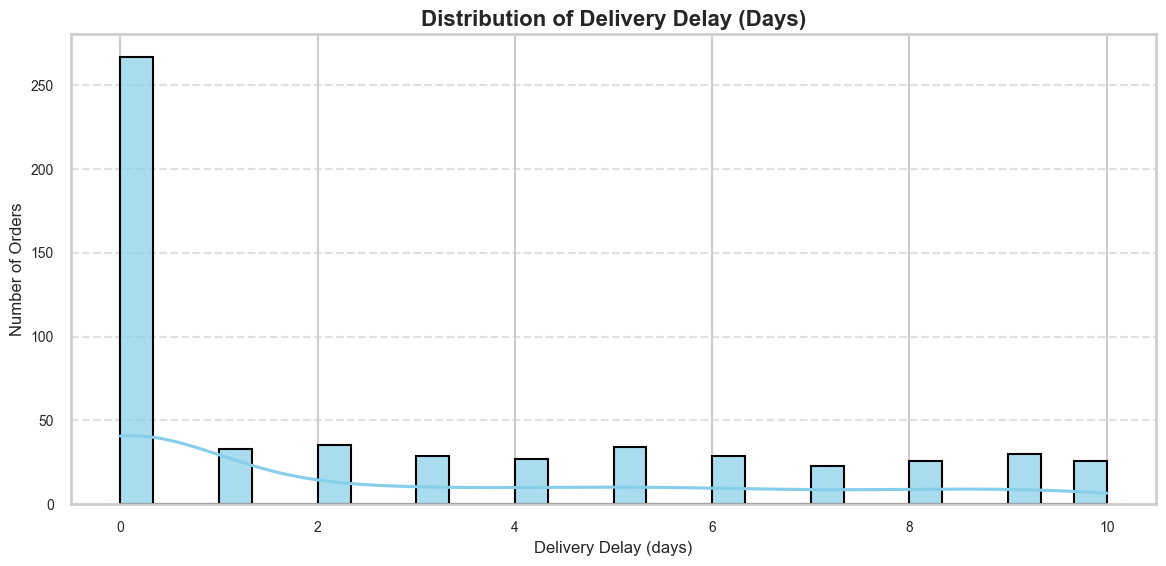

In [480]:
plt.figure(figsize=(12, 6))

sns.histplot(
    clean_data['delivery_delay_days'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.title('Distribution of Delivery Delay (Days)', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Delay (days)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 2. On-time vs. Late Deliveries

#### Key Insights:

1. **Nearly Even Split Between On-Time and Late Deliveries**:

   * **On-time deliveries**: 281 orders
   * **Late deliveries**: 292 orders
   * This suggests that **\~50% of orders are delayed**, which is **significant** and warrants closer investigation.

2. **Late Deliveries Slightly Outnumber On-Time Ones**:

   * The fact that late deliveries **exceed** on-time ones indicates **systemic or recurring issues** in the procurement or supply chain process.

3. **Potential SLA Non-Compliance**:

   * If your organization has **Service Level Agreements (SLAs)** with suppliers, this chart reveals a **high rate of potential SLA breaches**.

4. **Need for Supplier Performance Evaluation**:

   * This result reinforces the importance of analyzing **supplier-level timeliness**, which can help **identify and engage underperforming vendors**.




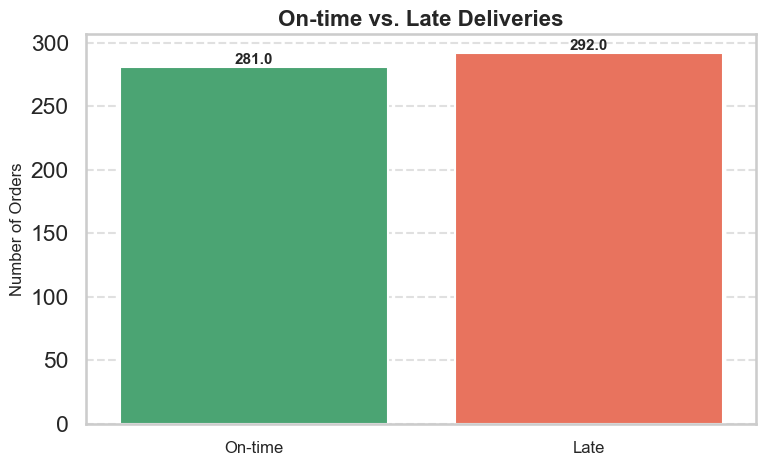

In [481]:
# Create the plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='is_late',
    hue='is_late',           # explicitly assign hue
    data=clean_data,
    palette={0: 'mediumseagreen', 1: 'tomato'},
    legend=False             # disable the automatic legend
)

# Set titles and labels
plt.title('On-time vs. Late Deliveries', fontsize=16, fontweight='bold')
plt.xticks([0, 1], ['On-time', 'Late'], fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add counts above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom',
                fontsize=11, fontweight='semibold')

plt.tight_layout()
plt.show()

### 3. Average Lead Time over Time


#### Key Insights:

**1. Fluctuations in Lead Time**

* The average lead time varies **significantly month to month**, showing **inconsistent supplier or logistics performance**.
* Notable spikes occur around **2022-02, 2023-01, and 2024-01**, indicating possible seasonal delays, procurement bottlenecks, or supply chain disruptions during those periods.

---

**2. Lead Time Dips**

* Some months (e.g., **2022-01, 2023-07**) show **notably shorter lead times**, which may reflect:

  * Efficient supplier performance
  * Local sourcing or improved logistics
  * Possibly lower volume or simpler orders

---

**3. Recent Increase (2023-12 → 2024-01)**

* A **sharp increase** in January 2024 (highest average lead time overall) suggests **new-year delays**, supplier backlogs, or procedural slowdowns.

---

**4. Presence of `NaT`**

* The presence of a `NaT` (Not a Time) label on the x-axis suggests **some records have missing or invalid delivery dates**.

  * These should be cleaned or filtered to avoid skewing time-based insights.




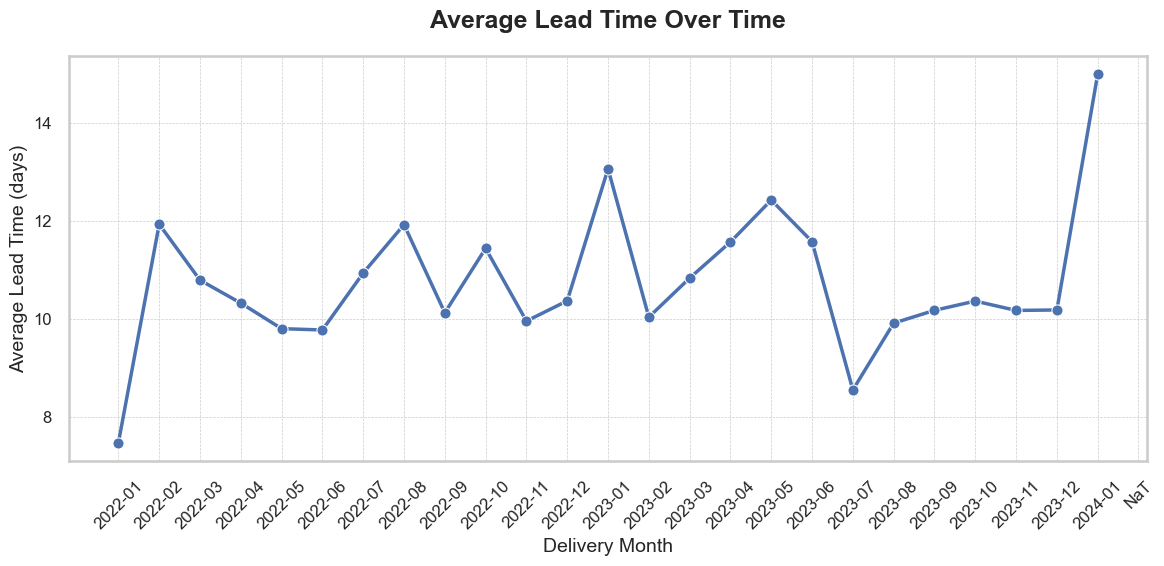

In [482]:
sns.set(style='whitegrid', context='talk', palette='deep')

monthly_lead_time = clean_data.groupby('delivery_month')['lead_time'].mean().reset_index()
monthly_lead_time['delivery_month'] = monthly_lead_time['delivery_month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_lead_time,
    x='delivery_month',
    y='lead_time',
    marker='o',
    linewidth=2.5,
    markersize=8
)

plt.title('Average Lead Time Over Time', fontsize=18, weight='bold', pad=20)
plt.xlabel('Delivery Month', fontsize=14)
plt.ylabel('Average Lead Time (days)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4. Late Delivery Rate by Supplier


#### Key Insights:

- **Alpha_Inc** has the highest late delivery rate (~58%), indicating a potential reliability issue.
- Even the best-performing supplier (**Gamma_Co**) still delivers late in ~43% of cases.
- This suggests that late deliveries are a **system-wide issue**, not limited to one vendor.
- The visualization helps identify **underperforming suppliers** and can guide procurement managers in **prioritizing supplier reviews**, adjusting SLAs, or developing **risk mitigation strategies**.

This chart is critical for monitoring supplier timeliness and improving overall delivery performance in the procurement process.


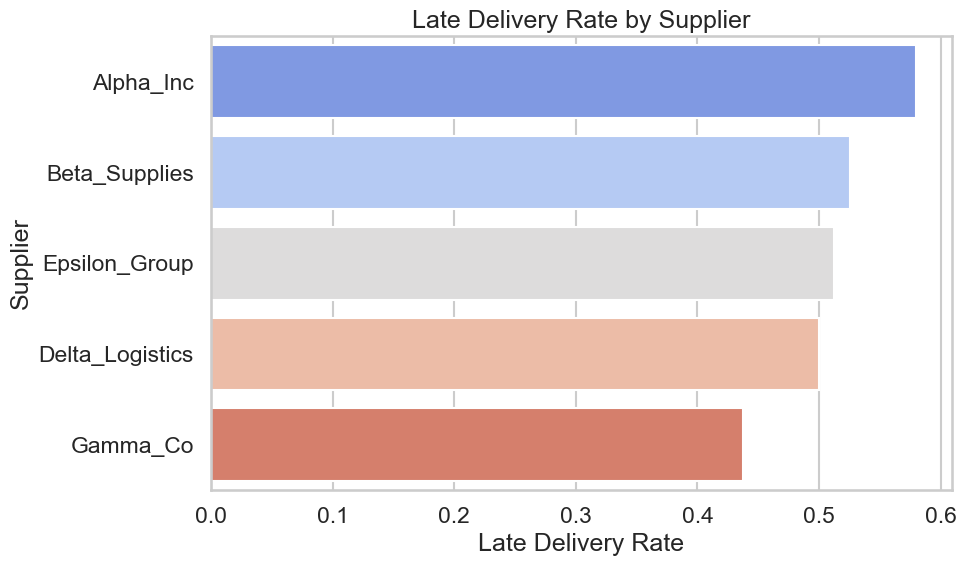

In [483]:
supplier_late_rate = clean_data.groupby('Supplier')['is_late'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=supplier_late_rate,
    x='is_late',
    y='Supplier',
    hue='Supplier',  # add hue
    palette='coolwarm',
    legend=False     # remove redundant legend
)
plt.title('Late Delivery Rate by Supplier')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Supplier')
plt.tight_layout()
plt.show()


## Cost Efficiency Metrics

| **Column Name**       | **Purpose / Insight**                                                        |
| --------------------- | ---------------------------------------------------------------------------- |
| `estimated_cost`      | Represents the total cost **without negotiation** — baseline for comparison. |
| `discounted_tot_cost` | The **actual total cost paid** after negotiation.                            |
| `discount_val`        | Absolute **cost savings** achieved through negotiation.                      |
| `total_savings_pct`   | **Normalized savings percentage** at the total transaction level.            |
| `price_variance` | Measures **price consistency** or fluctuation — helps detect pricing irregularities |


In [44]:
# clean_data['unit_savings']= clean_data['Unit_Price']-clean_data['Negotiated_Price']
# clean_data['savings_pct_unit_price']=(
#     100*(clean_data['unit_savings']/clean_data['Unit_Price']).where(clean_data['Unit_Price']>0,0)
# )
clean_data['estimated_cost']=clean_data['Quantity']*clean_data['Unit_Price']
# discounted total cost
clean_data['discounted_tot_cost']=clean_data['Quantity']*clean_data['Negotiated_Price']
# discount value
clean_data['discount_val']=clean_data['estimated_cost']-clean_data['discounted_tot_cost']
# discount percentage
clean_data['discount_pct']=(
    100*((clean_data['Unit_Price']-clean_data['Negotiated_Price'])/clean_data['Negotiated_Price']).\
        where(clean_data['Unit_Price']>0,0)
)
# total savings percentage
clean_data['total_savings_pct'] = (
    100 * (clean_data['discount_val'] / clean_data['estimated_cost']).where(clean_data['estimated_cost'] > 0, 0)
)

#Compute Price standard deviation per Supplier and Item_Category
price_var_combo = clean_data.groupby(['Supplier', 'Item_Category'])['Unit_Price'].std().reset_index()
price_var_combo.rename(columns={'Unit_Price': 'price_variance'}, inplace=True)

clean_data.head(1)

,index,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,DQ_Ind,lead_time,is_late,expected_delivery_date,delivery_delay_days,delivery_month,estimated_cost,discounted_tot_cost,discount_val,discount_pct,total_savings_pct
0,1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,0,10.0,0,2022-05-05,0.0,2022-05,59333.88,56346.06,2987.82,5.302625,5.035605


| **Column**                | **Data Type**      | **Summary of Findings**                                                                                                                                                           |
| ------------------------- | ------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **estimated\_cost**       | Continuous (Float) | No missing values. High variability (Min: 865.9, Max: 444,800). Right-skewed (Skew = 1.82), with some outliers (\~1.75%). Consider log transformation before modeling.            |
| **discounted\_tot\_cost** | Continuous (Float) | Similar profile to `estimated_cost`. Slightly lower average and standard deviation. Also right-skewed and contains outliers. Validate discount logic aligns with cost reductions. |
| **discount\_val**         | Continuous (Float) | No nulls. Represents absolute savings; skewed with long tail (Max: 28,474.8). High outlier rate (6.1%). Review extreme discount cases for validity.                               |
| **discount\_pct**         | Continuous (Float) | Percentage-based; clean distribution. Median = 8.25%, Max \~17.6%. Symmetric, no outliers. Ideal for use in modeling or as a feature.                                             |
| **total\_savings\_pct**   | Continuous (Float) | Similar to `discount_pct`. Clean, symmetric, and bounded as expected. No missing or extreme values. Reflects well-structured derived field.                                       |


In [45]:
data_prep.DatasetMetadata(clean_data[['estimated_cost','discounted_tot_cost','discount_val','discount_pct','total_savings_pct']],False)

,CName,DType,UsageMB,VarType,Cardinality,Null*,Empty*,Mode,Mean,Std,Min,Max,Skewness,Kurtosis,Q1,Q2/Median,Q3,Outliers %,Entropy,Max Entropy
0,estimated_cost,float64,0.0,Continuous,573,0,0,865.900000,63978.050838,51431.633010,865.900000,444800.000000,1.82,7.43,25789.800000,51231.300000,91130.380000,1.75,9.16,9.16
1,discounted_tot_cost,float64,0.0,Continuous,573,0,0,772.800000,59134.832583,48024.800933,772.800000,432900.000000,1.95,8.67,23256.000000,47836.800000,83956.600000,1.75,9.16,9.16
2,discount_val,float64,0.0,Continuous,573,0,0,43.020000,4843.218255,4886.682590,43.020000,28474.800000,1.85,3.82,1429.680000,3114.720000,6617.340000,6.11,9.16,9.16
3,discount_pct,float64,0.0,Continuous,573,0,0,1.015625,8.634652,4.877283,1.015625,17.636746,0.17,-1.24,4.270570,8.250265,12.814007,0.00,9.16,9.16
4,total_savings_pct,float64,0.0,Continuous,573,0,0,1.005414,7.763916,4.117966,1.005414,14.992548,0.08,-1.27,4.095662,7.621473,11.358525,0.00,9.16,9.16


###  1. Distribution of Total Savings %

#### Key Insights:
This plot visualizes the distribution of savings achieved on procurement orders, expressed as a percentage of the original (unit) price. It helps assess how effective negotiations or supplier agreements have been across all transactions.

---

1. **Wide Distribution of Savings**:

   * Savings range broadly from **1% to 15%**, indicating **inconsistent negotiation performance** or pricing flexibility across items/suppliers.

2. **Mean Savings ≈ 8%**:

   * The red dashed line shows the **average savings percentage** is around **8%**, which serves as a baseline for evaluating procurement effectiveness.
   * Categories or suppliers consistently **below this mean** could signal **missed savings opportunities**.

3. **No Single Dominant Peak**:

   * The distribution is **fairly flat**, suggesting there isn't one typical discount level.
   * This might mean that **discounts are highly context-dependent**, based on item, supplier, or negotiation timing.

4. **Optimization Potential**:

   * Orders with **<5% savings** form a significant share — a red flag for **low-efficiency negotiations**.
   * Procurement could benefit from:

     * Setting **minimum target discount thresholds**.
     * Prioritizing **high-spend items** for strategic negotiation.

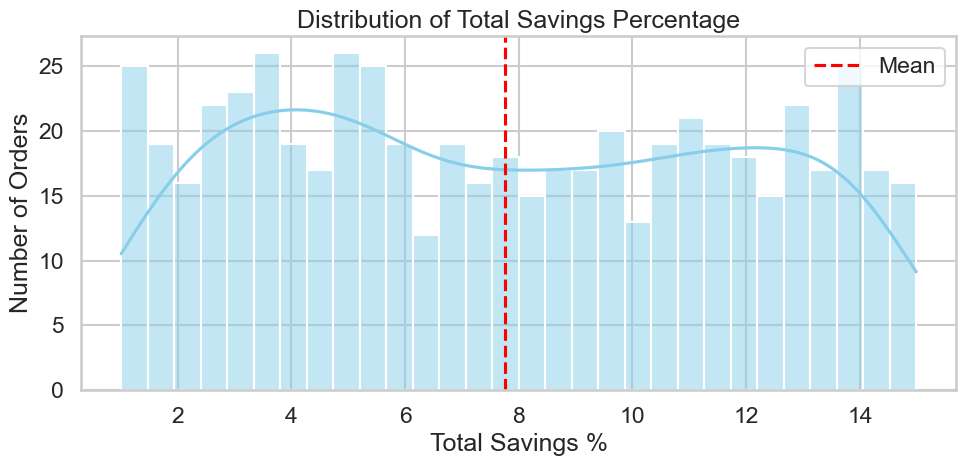

In [485]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_data['total_savings_pct'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Total Savings Percentage')
plt.xlabel('Total Savings %')
plt.ylabel('Number of Orders')
plt.axvline(clean_data['total_savings_pct'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()
plt.show()


### 2. Supplier-Wise Average Total Savings %

#### Key Insights

This **horizontal bar chart** compares the **average percentage savings** achieved per supplier across all procurement orders.


1. **Gamma\_Co delivers the highest average savings** (\~8%), suggesting strong negotiation leverage or pricing flexibility with this supplier.
2. All suppliers show **similar savings rates** (around 7.7–8%), implying a relatively consistent discounting strategy or procurement performance across suppliers.
3. While high savings are desirable, they may also signal **initial list prices are inflated** — worth investigating.
4. This metric should be interpreted **alongside supplier delivery performance** (e.g. from the Late Delivery Rate chart) for a balanced procurement decision.




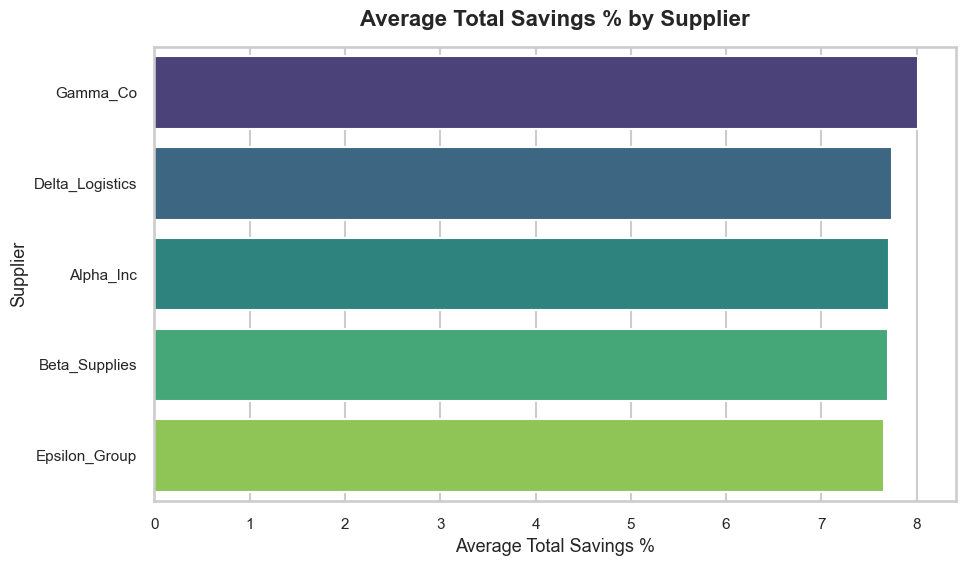

In [486]:
supplier_savings = clean_data.groupby('Supplier')['total_savings_pct'].mean().reset_index().sort_values('total_savings_pct', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=supplier_savings,
    x='total_savings_pct',
    y='Supplier',
    hue='Supplier',
    palette='viridis',
    legend=False
)
plt.title('Average Total Savings % by Supplier', fontsize=16, weight='bold', pad=15)
plt.xlabel('Average Total Savings %', fontsize=13)
plt.ylabel('Supplier', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()



### 3. Scatter Plot: Estimated vs Discounted Cost

### Key Insights
This scatter plot compares the **estimated cost** (based on list/unit price) versus the **actual discounted cost** (based on negotiated price) for each procurement order, with:
* **Each point** = an order.
* **Color** = supplier.
* **Red dashed line** = reference line where estimated cost = discounted cost (no savings).

---
1. **Most points fall below the red line**, indicating that **negotiated prices are generally lower** than unit prices — a sign of successful cost savings.
2. **No supplier consistently lies above the line**, so **no clear case of overspending** is observed.
3. **Larger savings (wider gap from the line)** occur more frequently in **high-value orders**, highlighting the impact of negotiations at scale.
4. **Color spread across the plot** shows that **all suppliers contribute to cost-saving**, not just one.





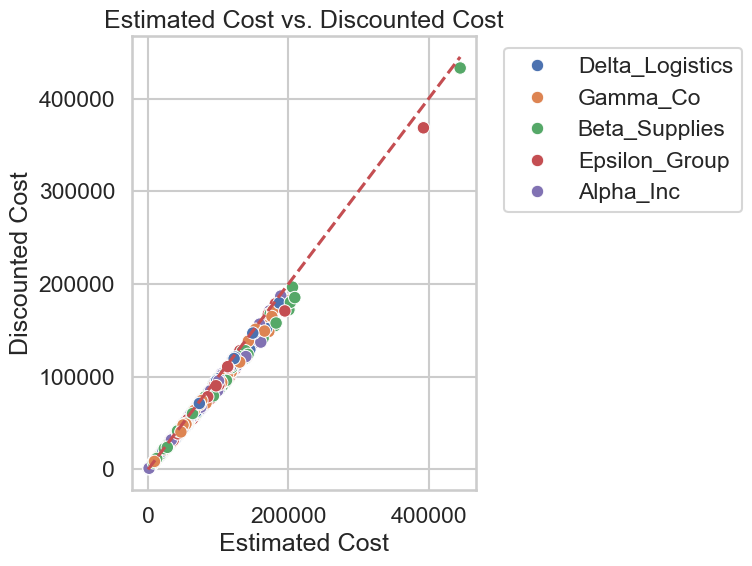

In [487]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=clean_data, x='estimated_cost', y='discounted_tot_cost', hue='Supplier')
plt.plot([0, clean_data['estimated_cost'].max()], [0, clean_data['estimated_cost'].max()], 'r--')  # Reference line
plt.title('Estimated Cost vs. Discounted Cost')
plt.xlabel('Estimated Cost')
plt.ylabel('Discounted Cost')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


###  4. Price Standard Deviation by Supplier and Item Category

### Key Insights

This **clustered bar chart** presents the **standard deviation of unit prices** for each item category across different suppliers. It helps identify where **price consistency** or **volatility** exists.

- **X-axis**: Standard deviation of unit prices (i.e., how much prices fluctuate).
- **Y-axis**: Supplier names.
- **Colors**: Represent different item categories.

---
1. **Packaging items from Beta_Supplies** show the **highest price variance**, indicating **inconsistent pricing** and potential for renegotiation or process review.
2. **Most suppliers show stable pricing** across Office Supplies and MRO items (Maintenance, Repair, Operations), suggesting those categories are relatively standardized.
3. **Electronics and Raw Materials** have moderate to high variability, especially from Alpha_Inc and Gamma_Co — likely due to market-driven pricing or inconsistent order specifications.
4. **Suppliers with high variance across multiple categories** (e.g., Beta_Supplies, Gamma_Co) may benefit from price benchmarking or more structured contracts.





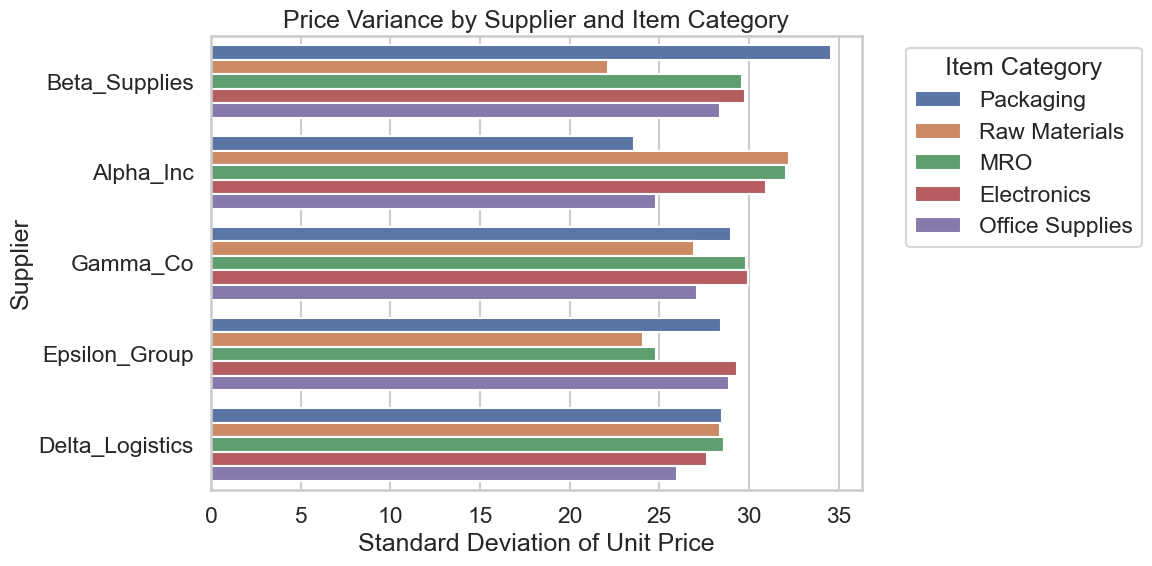

In [488]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=price_var_combo.sort_values('price_variance', ascending=False),
    x='price_variance',
    y='Supplier',
    hue='Item_Category'
)
plt.title('Price Variance by Supplier and Item Category')
plt.xlabel('Standard Deviation of Unit Price')
plt.ylabel('Supplier')
plt.legend(title='Item Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Quality Metrics

| **Metric Name**          | **Description**                                                             | **Purpose**                                                                |
| ------------------------ | --------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| `defect_rate_pct`        | Percentage of defective units relative to the total quantity in each order. | Measures the rate of defects per order to assess quality issues.           |
| `defect_flag`            | Binary flag: `0` if no defects in the order, `1` otherwise.                 | Tracks the proportion of completely defect-free orders.                    |
| `defects_per_1000_units` | Number of defects normalized per 1,000 units delivered.                     | Allows comparison of defect levels across orders of different sizes.       |
| `compliant_flag`         | Binary flag: `1` if the order is marked as compliant, `0` if non-compliant. | Measures supplier compliance with procurement terms.                       |
| `avg_defect_rate_pct`    | Average defect rate (from `defect_rate_pct`) per supplier.                  | Summarizes quality performance of each supplier.                           |
| `pct_zero_defect_orders` | Share of orders with zero defects per supplier (mean of `defect_flag`).     | Shows how frequently each supplier delivers completely defect-free orders. |
| `pct_compliant_orders`   | Share of compliant orders per supplier (mean of `compliant_flag`).          | Evaluates supplier adherence to contract or compliance standards.          |
| `cancelled_flag`         | Binary flag: `1` if `Order_Status` is “Cancelled”, `0` otherwise.           | Tracks the number and share of orders that were cancelled.                 |
| `pending_flag`           | Binary flag: `1` if `Order_Status` is “Pending”, `0` otherwise.             | Tracks the number and share of orders still awaiting fulfillment.          |


In [47]:
clean_data.head(1)

,index,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,DQ_Ind,lead_time,is_late,expected_delivery_date,delivery_delay_days,delivery_month,estimated_cost,discounted_tot_cost,discount_val,discount_pct,total_savings_pct
0,1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,0,10.0,0,2022-05-05,0.0,2022-05,59333.88,56346.06,2987.82,5.302625,5.035605


In [48]:
clean_data['Order_Status'].unique()

array(['Delivered', 'Partially Delivered', 'Pending', 'Cancelled'],
      dtype=object)

In [53]:
clean_data['defect_rate_pct']=(
    100*(clean_data['Defective_Units']/clean_data['Quantity']).\
    where(clean_data['Quantity']>0,0)
)

clean_data['defect_flag'] = np.where(
    clean_data['Defective_Units'] > 0,
    1,  # has defects
    0   # no defects
)

clean_data['compliant_flag'] = clean_data['Compliance'].map({'Yes': 1, 'No': 0})

clean_data['pending_flag'] = np.where(
    clean_data['Order_Status'] == 'Pending',
    1,  # Pending
    0   
)

clean_data['cancelled_flag'] = np.where(
    clean_data['Order_Status'] == 'Cancelled',
    1,  # Cancelled
    0   
)

quality_summary = clean_data.groupby('Supplier').agg({
    'defect_rate_pct': 'mean',
    'defect_flag': 'mean',
    'compliant_flag': 'mean'
}).rename(columns={
    'defect_rate_pct': 'avg_defect_rate_pct',
    'defect_flag': 'pct_zero_defect_orders',
    'compliant_flag': 'pct_compliant_orders'  
})


| **Column**            | **Data Type**        | **Summary of Findings**                                                                                                   |
| --------------------- | -------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| **defect\_rate\_pct** | Continuous (Float)   | No missing values. Range: 0.0–18.73%. Mean \~5.59%. Slight right skew (0.77). No outliers. Good KPI for quality tracking. |
| **defect\_flag**      | Categorical (Binary) | No nulls. **1 = order has defects**, 0 = no defects. Mean \~0.19 → \~19% of orders contain defects.                       |
| **compliant\_flag**   | Categorical (Binary) | No nulls. 1 indicates compliance. Mean \~0.82 → \~82% of orders meet compliance standards.                                |
| **pending\_flag**     | Categorical (Binary) | No nulls. Very low occurrence (mean \~1.05%). Indicates small proportion of orders still pending.                         |
| **cancelled\_flag**   | Categorical (Binary) | No nulls. Very low occurrence (mean \~1.4%). Tracks proportion of cancelled orders.                                       |
                                     |


In [55]:
data_prep.DatasetMetadata(clean_data[['defect_rate_pct','defect_flag','compliant_flag','pending_flag','cancelled_flag']],False)

,CName,DType,UsageMB,VarType,Cardinality,Null*,Empty*,Mode,Mean,Std,Min,Max,Skewness,Kurtosis,Q1,Q2/Median,Q3,Outliers %,Entropy,Max Entropy
0,defect_rate_pct,float64,0.0,Continuous,460,0,0,0.0,5.590430,5.022177,0.0,18.726592,0.77,-0.58,2.004454,3.750837,9.660767,0.00,7.87,8.85
1,defect_flag,int64,0.0,Categorical,2,0,0,1.0,0.811518,0.391438,0.0,1.000000,N/A,N/A,1.000000,1.000000,1.000000,18.85,0.70,1.00
2,compliant_flag,int64,0.0,Categorical,2,0,0,1.0,0.823735,0.381379,0.0,1.000000,N/A,N/A,1.000000,1.000000,1.000000,17.63,0.67,1.00
3,pending_flag,int64,0.0,Categorical,2,0,0,0.0,0.010471,0.101881,0.0,1.000000,N/A,N/A,0.000000,0.000000,0.000000,1.05,0.08,1.00
4,cancelled_flag,int64,0.0,Categorical,2,0,0,0.0,0.013962,0.117434,0.0,1.000000,N/A,N/A,0.000000,0.000000,0.000000,1.40,0.11,1.00


### 1. Order Status Breakdown

#### Key Insights: 

1. **Overwhelming Majority of Orders Are "Other" (Completed)**

   * **97.6%** of all purchase orders are classified as "Other," meaning they are **neither cancelled nor pending**.
   * This is a strong indicator of an efficient procurement or fulfillment process, with almost all orders being processed through to a final state (Delivered or Partially Delivered).

2. **Low Cancellation Rate**

   * Only **1.0%** of all orders were **cancelled**.
   * This suggests very few disruptions, changes in demand, or supplier issues leading to cancellations.

3. **Minimal Pending Orders**

   * Just **1.4%** of orders remain **pending**.
   * This reflects that the vast majority of orders are actively managed and completed, with very little backlog or orders stuck in limbo.

4. **Business/Operational Takeaway**

   * The process is well-controlled: The procurement team is successfully moving orders from initiation to closure.
   * The tiny share of cancelled and pending orders can be investigated further for root causes (e.g., recurring supplier, approval bottlenecks, or changing business needs), but are not a major operational concern.



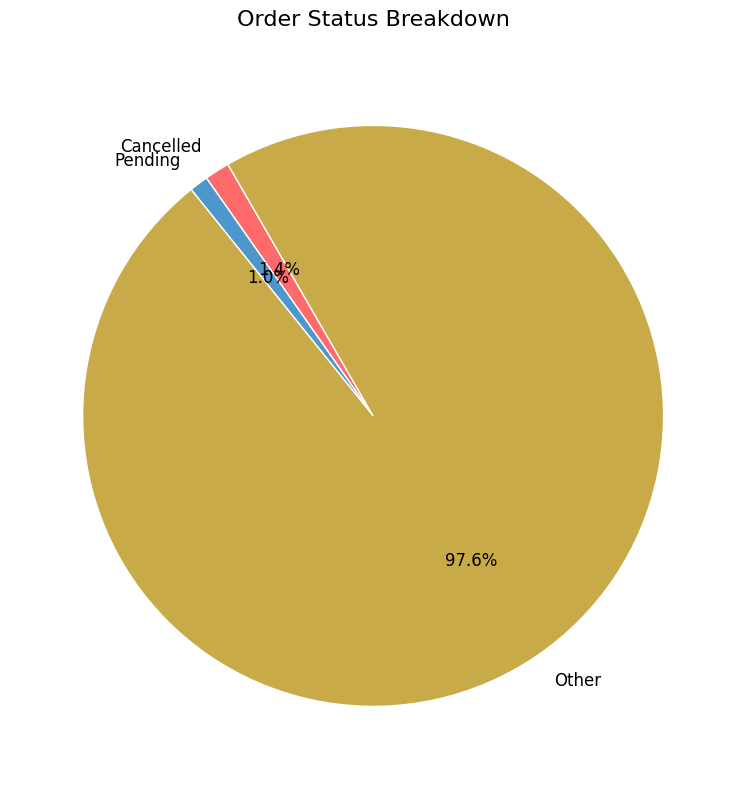

In [52]:
# Count each status
cancelled = clean_data['cancelled_flag'].sum()
pending = clean_data['pending_flag'].sum()
others = len(clean_data) - cancelled - pending

# Simple but appealing style
plt.figure(figsize=(8, 8))
plt.pie(
    [cancelled, pending, others],
    labels=['Cancelled', 'Pending', 'Other'],
    autopct='%1.1f%%',
    startangle=120,
    colors=['#ff6b6b', '#4e97cd', "#c8aa48"],  # Better colors
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},  # White edges
    textprops={'fontsize': 12}
)

plt.title('Order Status Breakdown', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 2. Distribution of defects units per number of orders

#### Key Insights:

* The distribution is **right-skewed**, with most orders having a relatively low number of defective units.
* A large peak near zero indicates **many orders have few or no defects**, but there are still orders with substantial defects.
* The long tail suggests **some orders have very high defect counts**, which could significantly impact overall quality and costs.
* This distribution helps identify the variability in order quality and highlights the need to investigate and address causes of high-defect orders.


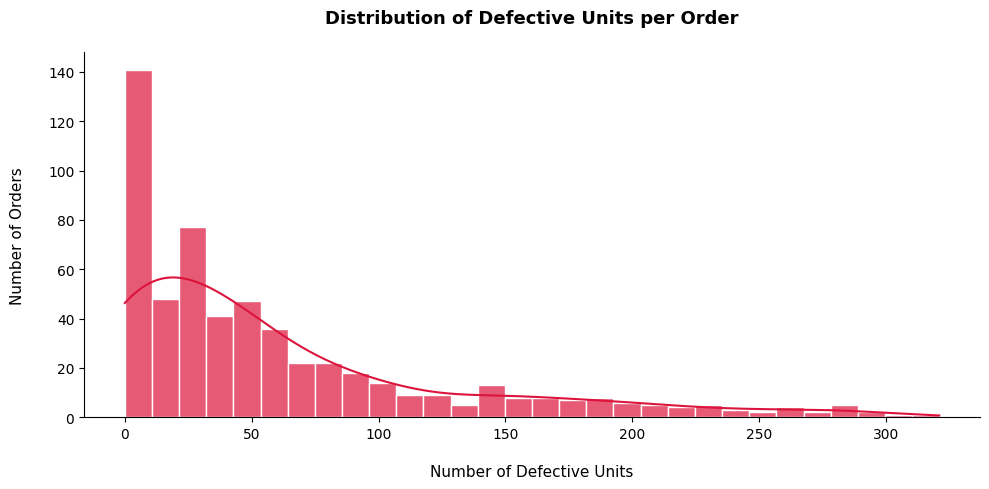

In [54]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_data['Defective_Units'], bins=30, kde=True,
             color='crimson', alpha=0.7, edgecolor='white')

plt.title('Distribution of Defective Units per Order\n', 
          fontweight='bold', fontsize=13)
plt.xlabel('\nNumber of Defective Units', fontsize=11)
plt.ylabel('Number of Orders\n', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### 3. Quality Summary by Supplier

#### Key Insights:

- **Beta_Supplies** and **Delta_Logistics** have the **highest average defect rates**, indicating more quality issues in their deliveries.
- **Epsilon_Group** and **Alpha_Inc** show relatively **low average defect rates**, suggesting better quality control.
- Suppliers like **Epsilon_Group** and **Alpha_Inc** also have a **high percentage of compliant orders** and **higher shares of zero-defect orders**, demonstrating consistent quality.
- **Gamma_Co** has a moderate defect rate but comparatively lower zero-defect order percentage and compliance, which could be an area for improvement.
- This comparison helps prioritize suppliers for quality improvement initiatives and supplier management focus.



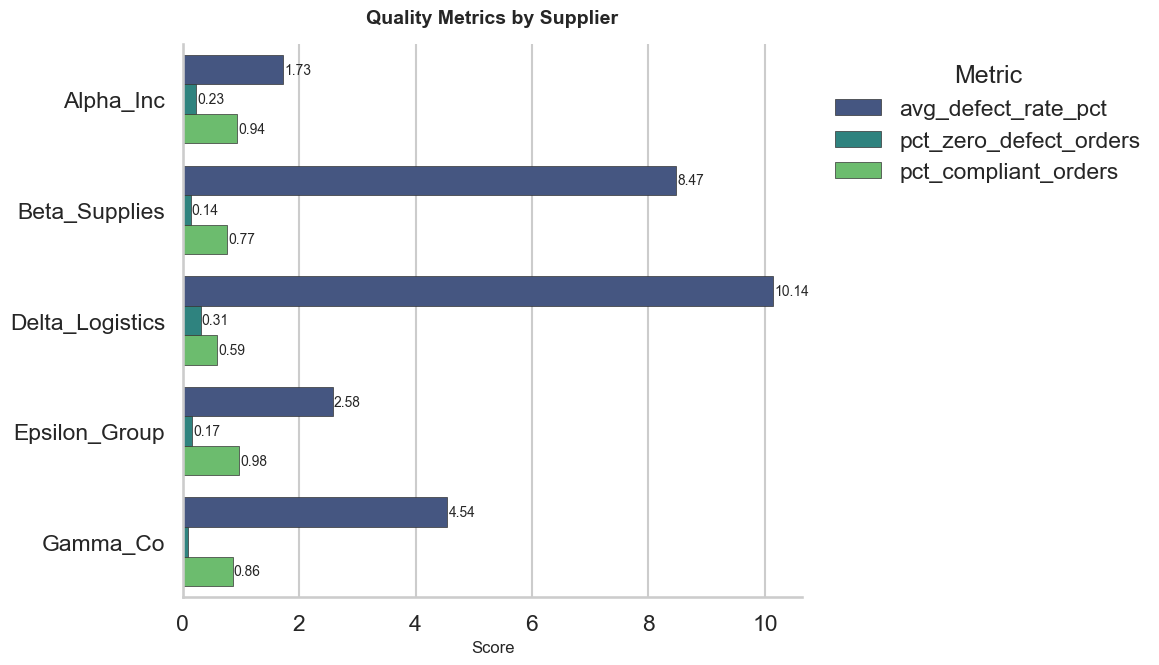

In [493]:
quality_summary_plot = quality_summary.reset_index().melt(id_vars='Supplier', var_name='Metric', value_name='Value')

# Set style and create plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=quality_summary_plot, x='Value', y='Supplier', hue='Metric',
                 palette="viridis", edgecolor='.2', linewidth=.5)

# Formatting
plt.title('Quality Metrics by Supplier', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('', fontsize=12)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), frameon=False)

# Add value labels if space allows
for p in ax.patches:
    if p.get_width() > 0.1:  # Only label significant values
        ax.text(p.get_width()+0.02, p.get_y()+p.get_height()/2, 
                f'{p.get_width():.2f}', va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()


## Supplier Performance

| Metric                       | Description                                                                                                                  |
| ---------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **avg\_lead\_time**          | Average time (in days) between order date and delivery date per supplier. Indicates typical delivery speed.                  |
| **std\_lead\_time**          | Standard deviation of lead times per supplier. Measures consistency/reliability of delivery timing.                          |
| **late\_delivery\_rate**     | Proportion of orders delivered later than the expected lead time (1 = late). Higher values indicate poorer timeliness.       |
| **total\_orders**            | Total number of purchase orders processed per supplier. Reflects order volume and supplier engagement.                       |
| **avg\_discount\_pct**       | Average negotiated discount percentage from the unit price. Shows supplier’s pricing competitiveness or negotiation success. |
| **avg\_defect\_rate\_pct**   | Average percentage of defective units per order per supplier. Reflects quality performance.                                  |
| **total\_defective\_units**  | Total count of defective units reported for all orders from the supplier. Measures overall defect burden.                    |
| **total\_quantity\_ordered** | Total quantity of units ordered from the supplier across all orders. Used to normalize defect counts.                        |
| **compliance\_rate**         | Proportion of orders marked compliant (`Compliance == 'Yes'`). Indicates adherence to requirements or contracts.             |


In [58]:
supplier_performance = clean_data.groupby('Supplier').agg({
    'lead_time': ['mean', 'std'],                       # avg lead time and variability
    'is_late': 'mean',                                  # late delivery rate (1 = late)
    'Order_Date': 'count',                              # total orders
    'discount_pct': 'mean',                             # avg discount %
    'defect_rate_pct': 'mean',                          # avg defect rate %
    'Defective_Units': 'sum',                           # total defective units
    'Quantity': 'sum',                                  # total quantity ordered
    'compliant_flag': 'mean'                            # compliance rate
})

# Flatten MultiIndex columns
supplier_performance.columns = [
    'avg_lead_time', 'std_lead_time', 'late_delivery_rate',
    'total_orders', 'avg_discount_pct', 'avg_defect_rate_pct',
    'total_defective_units', 'total_quantity_ordered', 'compliance_rate'
]

### 1. Average Lead Time per Supplier (with variability)
This bar chart shows the average lead time for each supplier. The error bars indicate variability (standard deviation), revealing consistency of delivery times.



#### Key Insights:

1. **Consistency vs. Variability**

   * Most suppliers have an **average lead time** clustered around 10–11 days, suggesting a generally predictable delivery pattern across your supply base.
   * The **error bars** (standard deviation) reveal **substantial variability** in some suppliers' delivery performance, which can impact planning reliability.

2. **Best and Worst Performers**

   * **Gamma\_Co** shows the **shortest average lead time**, making it a strong candidate for urgent orders.
   * **Beta\_Supplies** and **Epsilon\_Group** have slightly longer or more variable lead times, which may require closer management or adjusted expectations.

3. **Potential Risks**

   * Suppliers with **large standard deviations** (longer error bars) are less predictable, increasing risk of unexpected delays.
   * If certain suppliers consistently exceed their average lead time, it may be worth investigating root causes (e.g., process issues, supply chain disruptions).

4. **Opportunities for Improvement**

   * Collaborate with suppliers showing high variability to understand bottlenecks and improve their consistency.
   * Consider redistributing order volumes toward suppliers with shorter and more predictable lead times, where feasible.



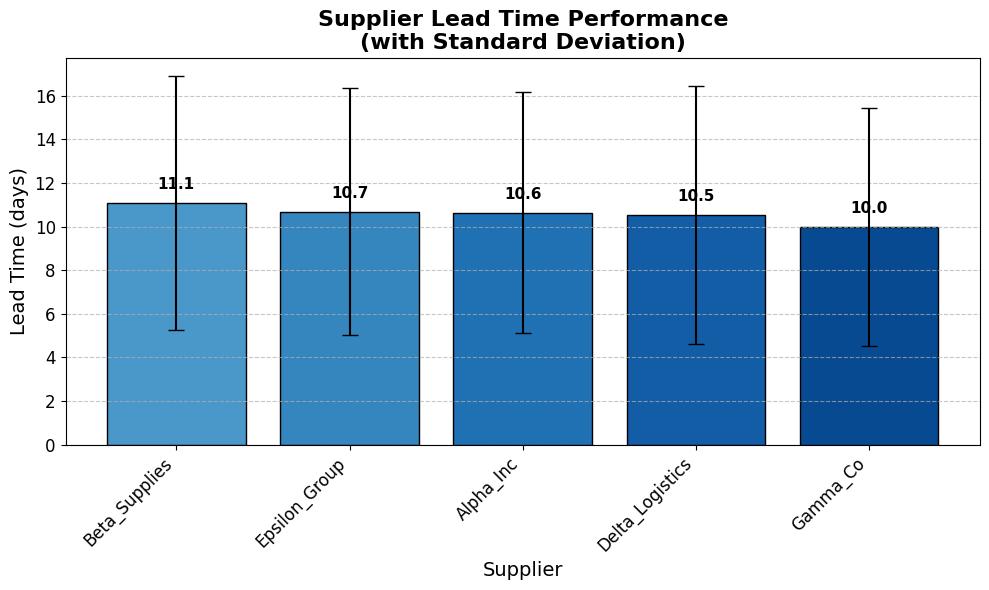

In [63]:
plt.figure(figsize=(10, 6))

# Sort data by average lead time descending (optional)
data_sorted = supplier_performance.sort_values('avg_lead_time', ascending=False)

bars = plt.bar(
    data_sorted.index,
    data_sorted['avg_lead_time'],
    yerr=data_sorted['std_lead_time'],
    capsize=6,
    color=plt.cm.Blues(np.linspace(0.6, 0.9, len(data_sorted))),
    edgecolor='black'
)

plt.title('Supplier Lead Time Performance\n(with Standard Deviation)', fontsize=16, fontweight='bold')
plt.xlabel('Supplier', fontsize=14)
plt.ylabel('Lead Time (days)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numeric labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()



### 2. Total Orders per Supplier

#### Key Insights:

1. **Epsilon_Group is the Top Supplier by Volume**
   - With **125 orders**, Epsilon_Group handles the most purchase orders, suggesting it is either a preferred supplier or offers broader product coverage.

2. **Orders Are Fairly Evenly Distributed**
   - The number of POs among suppliers ranges from **100 to 125**, indicating **no single supplier dominates** the procurement spend or operational flow.
   - This suggests a **diversified sourcing strategy**, which can reduce risk from supply disruptions.

3. **Alpha_Inc Has the Lowest Order Count**
   - At **100 orders**, Alpha_Inc is used less frequently than others, possibly due to niche products, higher prices, or performance issues.

4. **Opportunity for Strategic Review**
   - Suppliers with higher order volumes (Epsilon_Group, Delta_Logistics) could be **targeted for volume discounts or strategic partnerships**.
   - Conversely, suppliers with fewer orders may be reviewed for consolidation, performance improvement, or renegotiation.

5. **Balanced Sourcing**
   - No supplier appears to have less than 20% of the total orders, suggesting **no over-reliance** on a single partner.

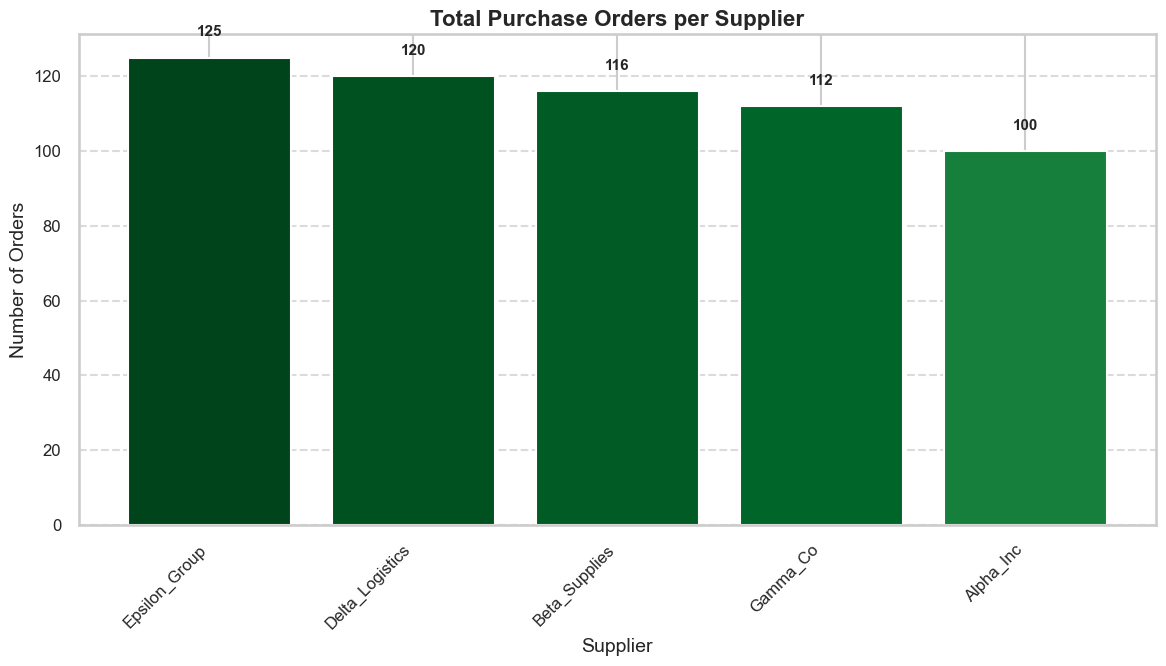

In [496]:
plt.figure(figsize=(12, 7))

# Sort suppliers by total_orders descending for better readability
supplier_performance_sorted = supplier_performance.sort_values('total_orders', ascending=False)

bars = plt.bar(
    supplier_performance_sorted.index,
    supplier_performance_sorted['total_orders'],
    color=plt.cm.Greens(supplier_performance_sorted['total_orders'] / supplier_performance_sorted['total_orders'].max())
)

plt.title('Total Purchase Orders per Supplier', fontsize=16, weight='bold')
plt.xlabel('Supplier', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()

### 3. Scatter Plot: Discount % vs. Defect Rate, colored by Compliance
Visualize tradeoff between negotiated discounts and defect rates, color-coded by compliance rate.

#### Key Insights:

1. **Best Overall Performers:**

   * **Alpha\_Inc** and **Epsilon\_Group** stand out:

     * **Low defect rates** 
     * **High compliance rates** (deep red),
     * **Decent discounts** (left side, but not the absolute highest).
   * These suppliers represent the *ideal balance* of quality, compliance, and savings.

2. **Quality vs. Cost Savings Tradeoff:**

   * **Delta\_Logistics** and **Beta\_Supplies** offer **comparable discounts** but at the cost of **higher defect rates** and **lower compliance** (greener/yellower color).
   * **Gamma\_Co** provides the **highest average discount**, but its defect rate is noticeably higher than Alpha\_Inc or Epsilon\_Group, and its compliance is not as strong (orange).

3. **Supplier Selection Strategy:**

   * If your **priority is quality and compliance** (e.g., critical materials), Alpha\_Inc and Epsilon\_Group are top picks—even if their discounts aren't the very highest.
   * For **cost-driven procurement** where some quality tradeoff is acceptable, Gamma\_Co might be suitable, but **monitor for defect-related risks**.

4. **Opportunity for Supplier Development:**

   * **Delta\_Logistics** and **Beta\_Supplies** could be targeted for supplier development or stricter quality controls to bring their defect rates down closer to the high-performing suppliers.


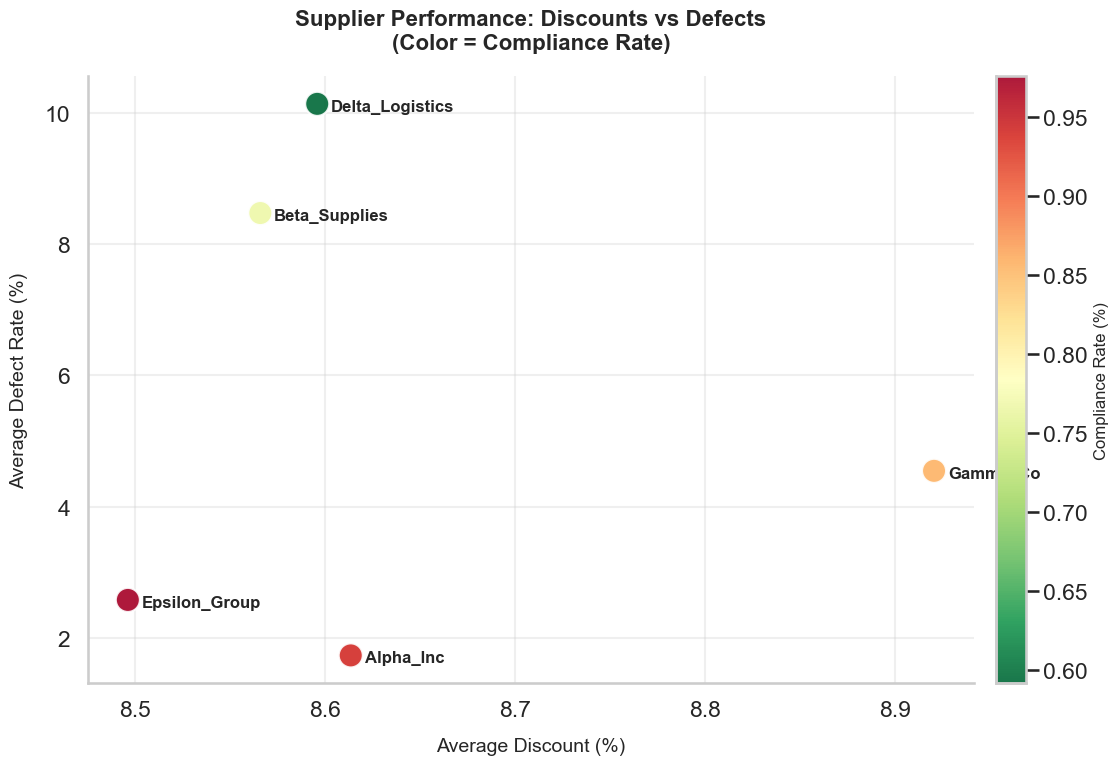

In [497]:
plt.figure(figsize=(12, 8))  # Slightly larger figure

scatter = plt.scatter(
    x='avg_discount_pct',
    y='avg_defect_rate_pct',
    c='compliance_rate',
    data=supplier_performance,
    cmap='RdYlGn_r',
    s=300,  # Increased marker size from 200 to 300
    edgecolor='w',
    linewidth=1.5,
    alpha=0.9
)

# Formatting
cbar = plt.colorbar(scatter, label='Compliance Rate (%)', pad=0.02)
cbar.ax.yaxis.label.set_size(12)  # Larger colorbar label

plt.xlabel('Average Discount (%)', fontsize=14, labelpad=12)  # Increased font size
plt.ylabel('Average Defect Rate (%)', fontsize=14, labelpad=12)  # Increased font size
plt.title('Supplier Performance: Discounts vs Defects\n(Color = Compliance Rate)', 
          fontweight='bold', pad=20, fontsize=16)  # Larger title

# Annotate points with larger text
for i, row in supplier_performance.iterrows():
    plt.annotate(i, (row['avg_discount_pct'], row['avg_defect_rate_pct']),
                 xytext=(10, -5),  # Slightly larger offset
                 textcoords='offset points',
                 fontsize=12,  # Increased from 9 to 12
                 ha='left',
                 weight='bold')  # Added bold

plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## Category or Product-Level Metric

In [ ]:
# Create price bands
clean_data['price_band'] = pd.cut(clean_data['Unit_Price'],
                                  bins=[0, 25, 50, 75, 100, clean_data['Unit_Price'].max()],
                                  labels=['0-25','25-50','50-75','75-100','100+'])

### 1. Total Cost & Savings by Category

#### Key insights:

**1. Highest Cost & Savings Category**

* **MRO** has:

  * The **highest total cost** at **7.89 million**.
  * The **highest total savings** at **663k**.
* Indicates a significant spend area with notable savings impact.

---

**2. Office Supplies & Raw Materials**

* **Office Supplies**: 2nd highest cost (**7.1M**) and savings (**558k**).
* **Raw Materials**: 3rd in cost (**6.63M**) and savings (**546k**).
* These are substantial procurement areas that should be monitored for cost optimization.

---

**3. Electronics & Packaging**

* Both have similar total costs (\~6.1M), but slightly **lower savings** compared to the top three.

  * **Electronics** savings: **489k**
  * **Packaging** savings: **518k**
* May suggest limited savings opportunities or under-optimized procurement strategies.

---

**4. Savings-to-Cost Efficiency**

While absolute savings are higher in high-spend categories, **savings as a percentage of cost** might be more revealing:

* **Packaging** seems relatively efficient—lower cost but still substantial savings.
* A deeper look into savings ratio (%) could identify underperforming categories in cost efficiency.



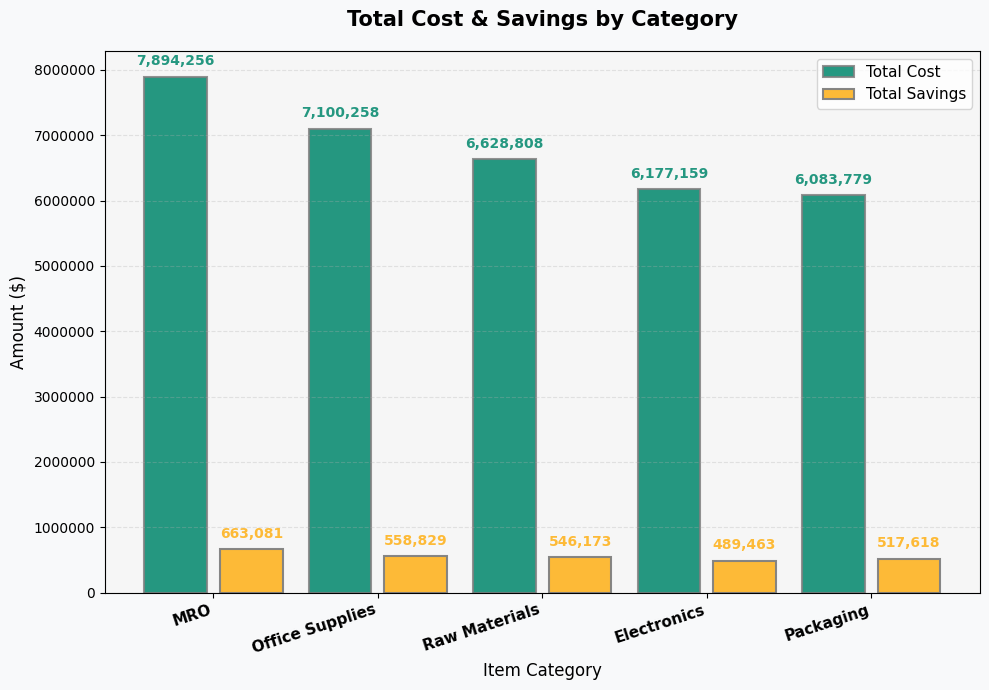

In [72]:
# Single groupby with agg
cost_savings = clean_data.groupby('Item_Category').agg({
    'discounted_tot_cost': 'sum',
    'discount_val': 'sum'
}).reset_index().rename(columns={
    'discounted_tot_cost': 'Total Cost',
    'discount_val': 'Total Savings'
})

# Sort by 'Total Spend' (descending)
cost_savings = cost_savings.sort_values('Total Cost', ascending=False)
categories = cost_savings['Item_Category']

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

bar_width = 0.38
bar_space = 0.08
x = np.arange(len(categories))

colors = ['#00876c', '#feb72c']  # Teal & Gold

# Bars
bars1 = ax.bar(x - bar_width/2 - bar_space/2, cost_savings['Total Cost'],
               bar_width, label='Total Cost', color=colors[0], alpha=0.85, edgecolor='grey', linewidth=1.5)
bars2 = ax.bar(x + bar_width/2 + bar_space/2, cost_savings['Total Savings'],
               bar_width, label='Total Savings', color=colors[1], alpha=0.95, edgecolor='grey', linewidth=1.5)

# Value labels (formatted with commas)
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f"{height:,.0f}", 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=bar.get_facecolor())

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=18, ha='right', fontsize=11, fontweight='semibold')
ax.set_title('Total Cost & Savings by Category', fontsize=15, fontweight='bold', pad=18)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_xlabel('Item Category', fontsize=12)
ax.legend(title='', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Disable scientific notation
ax.ticklabel_format(axis='y', style='plain')  # <-- THIS FIXES THE 1e6 ISSUE

plt.tight_layout()
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f6f6f6')
plt.show()



### 2. Average Discount vs. Defect Rate by Item Category

#### Key Insights:

**1. Average Discounts**

* **Highest discounts** are offered in **Packaging (9.2%)** and **Raw Materials (8.9%)**.
* **Lowest average discount** is in **Office Supplies (8.0%)**, though still close to the rest.
* The variation in discount percentages is relatively small (range \~8.0–9.2%), suggesting consistent discounting policies across categories.

---

**2. Average Defect Rates**

* **Office Supplies** has the **highest defect rate** at **6.1%**, despite having the lowest discount.
* **Packaging** has the **lowest defect rate** at **5.1%**, and also the highest discount — potentially a positive signal of quality despite price reductions.
* Defect rates for **Raw Materials (5.8%)**, **MRO (5.3%)**, and **Electronics (5.6%)** are all in a narrow range.

---

**3. Discounts vs. Defect Rate Relationship**

* No clear correlation between higher discounts and higher defect rates — e.g., Packaging offers the biggest discount but also the lowest defect rate.
* Office Supplies stands out negatively — **lowest discount but highest defect rate**, possibly indicating quality control issues without compensatory price adjustments.

---

**4. Business Implications**

* **Packaging** appears to be the best performer — **high discount + low defect rate** — could be used as a benchmark.
* **Office Supplies** requires attention — **highest defect rate** may affect customer satisfaction and increase returns/rework costs.
* Consistent discounting across most categories may suggest a uniform procurement/negotiation strategy, but performance (quality) varies.




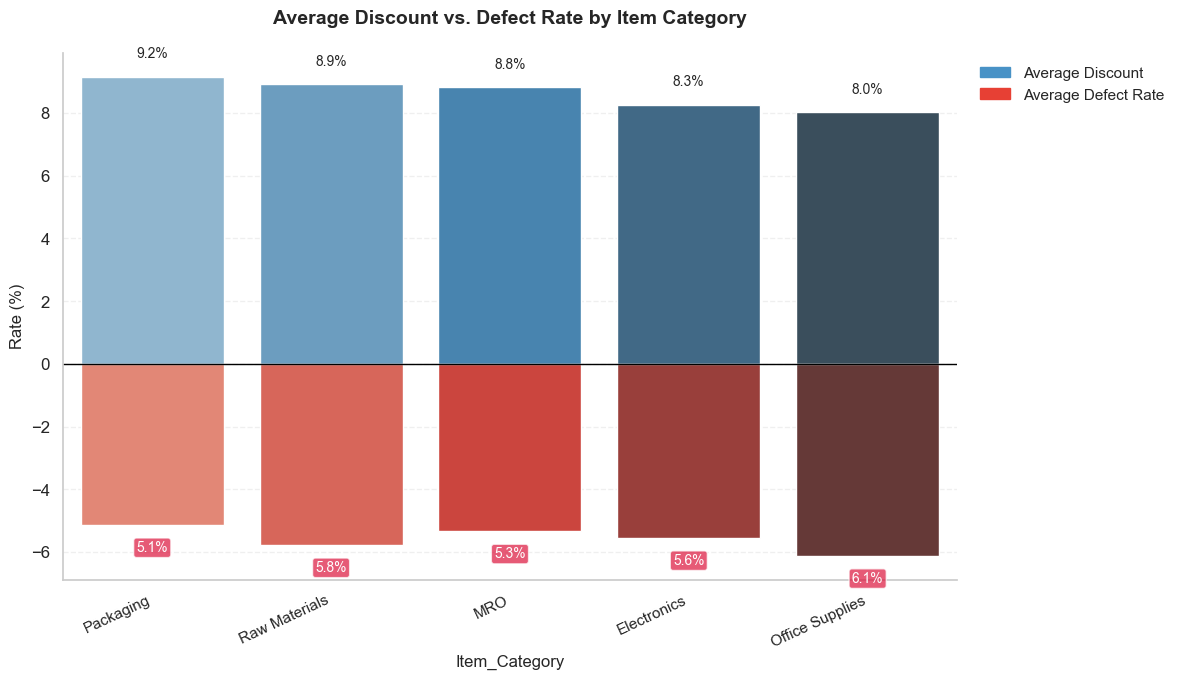

In [588]:
# Step 1: Compute means
summary = clean_data.groupby('Item_Category')[['discount_pct', 'defect_rate_pct']].mean().reset_index()
summary['neg_defect_rate_pct'] = -summary['defect_rate_pct']
summary = summary.sort_values('discount_pct', ascending=False).reset_index(drop=True)

# Step 2: Set up figure
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Set xticks explicitly for consistent tick handling
xticks = list(range(len(summary)))
ax.set_xticks(xticks)
ax.set_xticklabels(summary['Item_Category'], rotation=25, ha='right', fontsize=11)

# Step 3: Plot bars
# Discount bars (blue hue)
sns.barplot(
    x=summary['Item_Category'],
    y=summary['discount_pct'],
    hue=summary['Item_Category'],
    palette='Blues_d',
    legend=False,
    ax=ax
)

# Defect Rate bars (red hue, negative)
sns.barplot(
    x=summary['Item_Category'],
    y=summary['neg_defect_rate_pct'],
    hue=summary['Item_Category'],
    palette='Reds_d',
    legend=False,
    ax=ax
)

# Step 4: Add value labels
for i, row in summary.iterrows():
    # Discount label
    ax.text(i, row['discount_pct'] + 0.5, f"{row['discount_pct']:.1f}%",
            ha='center', va='bottom', fontsize=10)
    # Defect label
    ax.text(i, row['neg_defect_rate_pct'] - 0.5, f"{row['defect_rate_pct']:.1f}%",
            ha='center', va='top', fontsize=10, color='white',
            bbox=dict(facecolor='crimson', alpha=0.7, boxstyle='round,pad=0.2'))

# Step 5: Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title('Average Discount vs. Defect Rate by Item Category\n', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

# Step 6: Manual Legend (outside top right)
discount_patch = mpatches.Patch(color=sns.color_palette('Blues_d')[2], label='Average Discount')
defects_patch = mpatches.Patch(color=sns.color_palette('Reds_d')[2], label='Average Defect Rate')
ax.legend(handles=[discount_patch, defects_patch], loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=11, frameon=False)

plt.tight_layout()
plt.show()


### 3. Order Count by Price Band and Item Category

#### Key Insights:
---

**1. Most Common Price Bands**

* The **25–50**, **50–75**, and **75–100** price bands have the highest order counts (\~140–145 orders each).
* The **100+** price band has the lowest number of orders (\~42), indicating high-value orders are relatively rare.
* The **0–25** price band is also less common, suggesting low-price transactions are less frequent.

---

**2. Category Distribution by Price Band**

* **Electronics** and **MRO** have strong representation in the **75–100** price band.
* **Office Supplies** is fairly consistent across the 25–50, 50–75, and 75–100 bands but drops sharply at 0–25 and 100+.
* **Packaging** orders are more concentrated in the **25–50** range, with moderate counts in 0–25 and 50–75.
* **Raw Materials** are consistently present in the mid-price bands (25–75), less so in 0–25 and 100+.

---

**3. High-Value Orders (100+ Price Band)**

* Very few categories dominate this band; mainly **MRO**, **Office Supplies**, and **Raw Materials**.
* **Electronics** and **Packaging** have minimal high-value transactions here.

---

**4. Potential Business Implications**

* **Mid-range pricing (25–100)** appears to be the core transaction zone, possibly indicating target pricing sweet spots.
* **High-value orders (100+)** are rare and could be analyzed further to understand the drivers behind them (e.g., bulk purchases, premium products).
* Low-value orders (0–25) are also infrequent, which may mean minimum purchase thresholds or limited small-scale transactions.


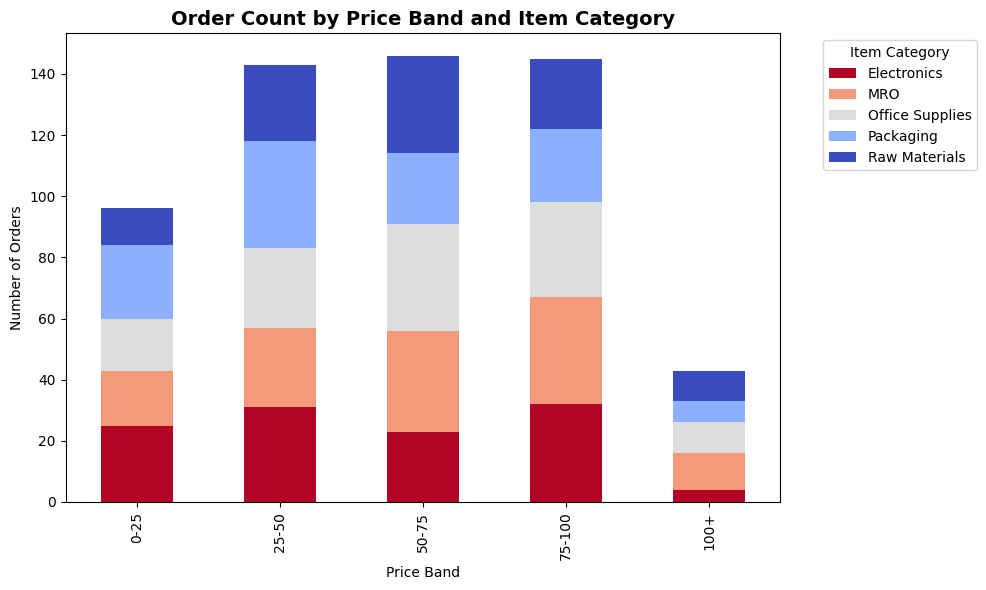

In [76]:
# Create price bands (example: quartiles)
clean_data['price_band'] = pd.cut(clean_data['Unit_Price'],
                                  bins=[0, 25, 50, 75, 100, clean_data['Unit_Price'].max()],
                                  labels=['0-25','25-50','50-75','75-100','100+'])
# Crosstab for counts per category & price band
crosstab = pd.crosstab(clean_data['price_band'], clean_data['Item_Category'])

# Stacked bar plot
crosstab.plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm_r',
    figsize=(10, 6)
)
plt.title('Order Count by Price Band and Item Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Band')
plt.ylabel('Number of Orders')
plt.legend(title='Item Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 4. Supplier Order Share by Item Category

#### Key Insights

**1. Supplier Diversity Across Categories**

* **All five suppliers (Alpha\_Inc, Beta\_Supplies, Delta\_Logistics, Epsilon\_Group, Gamma\_Co)** are present in all top 5 item categories.
* Indicates a **well-diversified supplier base**, reducing reliance on a single vendor.

---

**2. No Dominant Supplier**

* **No supplier exceeds 26% share** in any category:

  * Highest is **Gamma\_Co (26%)** in *Raw Materials*.
  * Second highest is **Epsilon\_Group (24%)** in *Electronics*.
* Suggests **balanced order distribution**, reducing vendor risk.

---

**3. Top Supplier per Category**

| Category        | Top Supplier     | Share |
| --------------- | ---------------- | ----- |
| MRO             | Epsilon\_Group   | 23%   |
| Office Supplies | Beta\_Supplies   | 23%   |
| Electronics     | Epsilon\_Group   | 24%   |
| Packaging       | Delta\_Logistics | 22%   |
| Raw Materials   | Gamma\_Co        | 26%   |

* **Epsilon\_Group** is top supplier for **MRO** and **Electronics**.
* **Delta\_Logistics** and **Gamma\_Co** also appear as top suppliers in one category each.

---

**4. Raw Materials – Highest Supplier Concentration**

* Gamma\_Co (26%) and Delta\_Logistics (25%) together control **51% of orders**.
* This suggests a **higher concentration** than other categories—potential risk if either supplier underperforms.

---

**5. MRO – Most Even Distribution**

* MRO orders are most evenly split:

  * All suppliers between **17% to 23%**.
* Implies **low dependency risk** and better negotiating leverage.



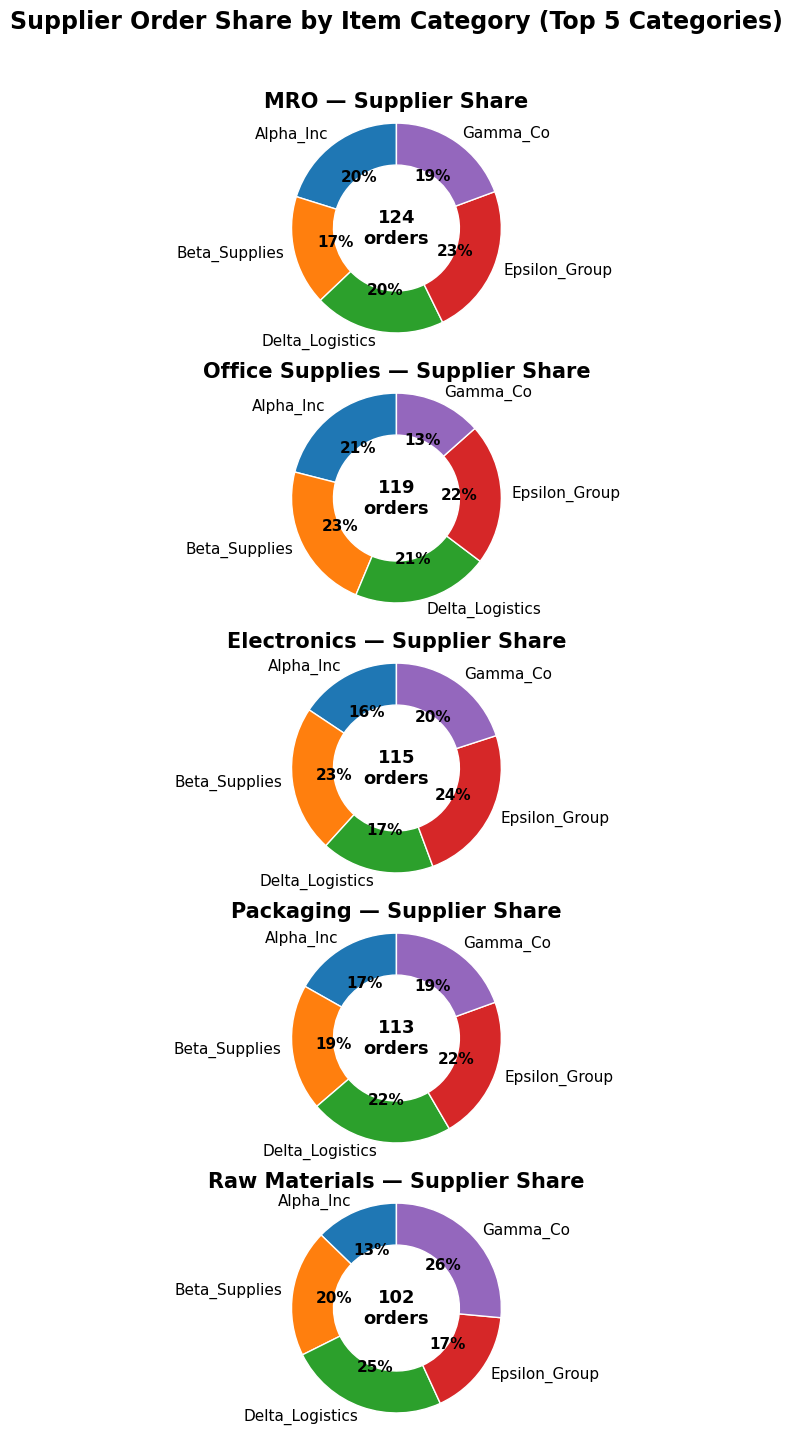

In [79]:
# Prepare order shares for top 5 categories
order_shares = (
    clean_data.groupby(['Item_Category', 'Supplier'])
    .size()
    .reset_index(name='Order_Count')
)
top_categories = order_shares.groupby('Item_Category')['Order_Count'].sum().nlargest(5).index
order_shares_top = order_shares[order_shares['Item_Category'].isin(top_categories)]

n_cats = len(top_categories)
fig, axes = plt.subplots(n_cats, 1, figsize=(8, 2.8 * n_cats))  # Vertical layout

if n_cats == 1:
    axes = [axes]

for ax, cat in zip(axes, top_categories):
    cat_data = order_shares_top[order_shares_top['Item_Category'] == cat]
    sizes = cat_data['Order_Count']
    suppliers = cat_data['Supplier']
    colors = sns.color_palette('tab10', len(suppliers))
    wedges, texts, autotexts = ax.pie(
        sizes, labels=suppliers, autopct='%1.0f%%', startangle=90,
        colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'), textprops={'fontsize': 11}
    )
    ax.set_title(f"{cat} — Supplier Share", fontsize=15, fontweight='bold')
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    ax.text(0, 0, f"{sizes.sum()}\norders", ha='center', va='center', fontsize=13, fontweight='bold')
    ax.axis('equal')

plt.suptitle("Supplier Order Share by Item Category (Top 5 Categories)", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### 5. Delivery Performance by Product Category


#### Key Insights
---

**1. Overall Poor On-Time Performance**

* **All categories have on-time rates below 55%**, indicating a **widespread delivery issue**.
* The **best performing category** (*Office Supplies*) still has **only 54.6%** on-time rate.
* Highlights a **systemic delivery reliability problem** across all product categories.

---

**2. MRO – Worst Delivery Performance**

* **Only 40.3% on-time**, with **59.7% of MRO orders delayed**.
* This is especially concerning since **MRO has the highest total spend** (from earlier chart).
* Implies **significant operational risk**—delays in MRO can halt production or maintenance.

---

**3. Electronics & Packaging – Nearly Even Split**

* Both have **exactly 50.4% delayed** and **49.6% on-time** deliveries.
* Suggests **inconsistent supplier performance** in these categories.

---

**4. Raw Materials – Slightly Better**

* **52% on-time rate**, making it the **second-best performing** category.
* Could indicate **room to optimize further**, possibly by focusing on top-performing suppliers.

---

**5. Office Supplies – Most Reliable**

* **Highest on-time delivery rate** at **54.6%**.
* While still below ideal, it outperforms all other categories.
* May serve as a **benchmark for best practices** in delivery management.



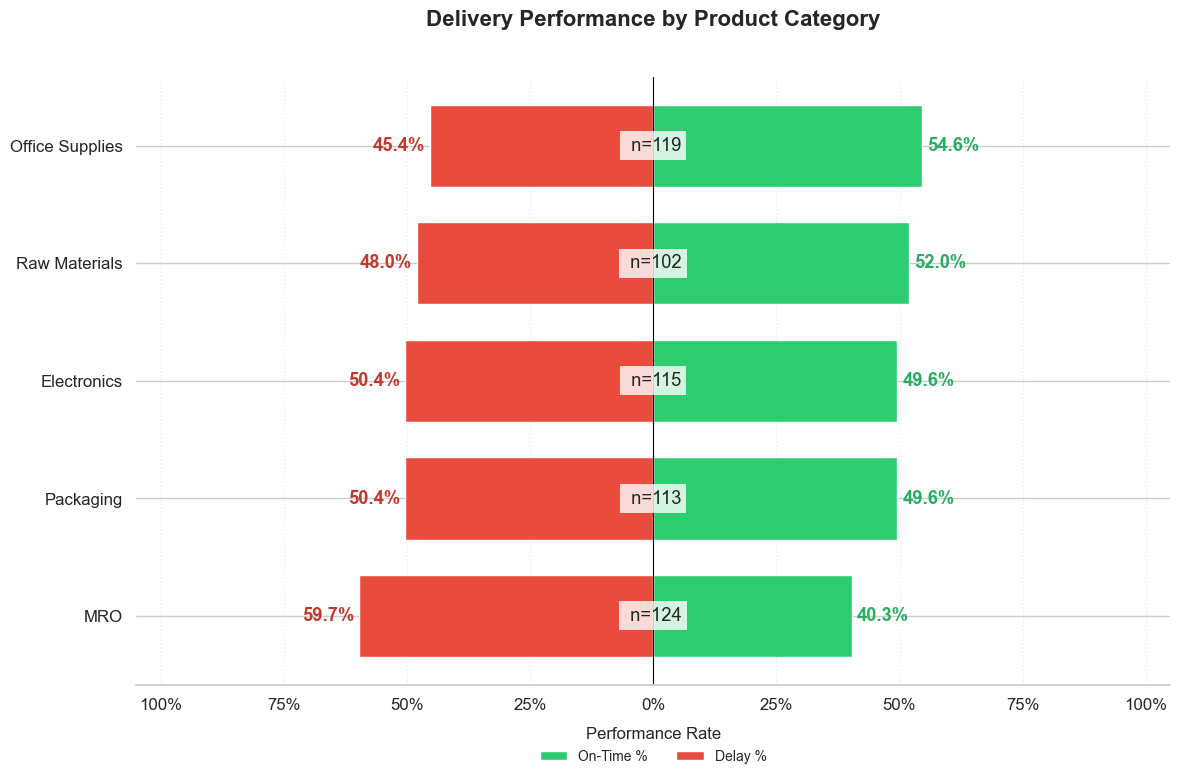

In [603]:
plt.figure(figsize=(12, 8))

# Calculate rates
category_ontime = clean_data.groupby('Item_Category')['is_late'].agg(['mean', 'count']).reset_index()
category_ontime['on_time_rate'] = (1 - category_ontime['mean']) * 100  # Convert to percentage
category_ontime['delay_rate'] = category_ontime['mean'] * 100
category_ontime_sorted = category_ontime.sort_values('on_time_rate', ascending=True)

# Create diverging bars
bar_width = 0.7
y_pos = np.arange(len(category_ontime_sorted))

# On-time bars (right)
plt.barh(y_pos, category_ontime_sorted['on_time_rate'], 
         height=bar_width, color='#2ecc71', edgecolor='white', label='On-Time %')

# Delay bars (left)
plt.barh(y_pos, -category_ontime_sorted['delay_rate'], 
         height=bar_width, color='#e74c3c', edgecolor='white', label='Delay %')

# Add value labels
for i, (ontime, delay) in enumerate(zip(category_ontime_sorted['on_time_rate'], 
                                      category_ontime_sorted['delay_rate'])):
    # On-time labels (right)
    plt.text(ontime + 1, i, f'{ontime:.1f}%', 
             va='center', color='#27ae60', fontweight='bold')
    
    # Delay labels (left)
    plt.text(-delay - 1, i, f'{delay:.1f}%', 
             va='center', color='#c0392b', fontweight='bold',
             ha='right')

# Reference line and formatting
plt.axvline(0, color='black', linewidth=0.8)
plt.yticks(y_pos, category_ontime_sorted['Item_Category'])
plt.xticks(ticks=[-100, -75, -50, -25, 0, 25, 50, 75, 100],
           labels=['100%', '75%', '50%', '25%', '0%', '25%', '50%', '75%', '100%'])

# Add order volume indicators
for i, count in enumerate(category_ontime_sorted['count']):
    plt.text(0, i, f' n={count}', va='center', ha='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title and labels
plt.title('Delivery Performance by Product Category\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Performance Rate', fontsize=12, labelpad=10)
plt.ylabel('', fontsize=12)
plt.xlim(-105, 105)

# Legend and grid
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.grid(axis='x', linestyle=':', alpha=0.4)

sns.despine(left=True)
plt.tight_layout()
plt.show()